# ===========================
# E-commerce Churn + Retention A/B Test Project
# ===========================

# 1️⃣ Import Libraries

In [26]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

 #---------------------------
# 2️⃣ Load Dataset

# ------------------------

In [27]:

df = pd.read_csv(r"C:\Users\drohi\Downloads\E-commerce.csv")

print(df.head())


   Customer ID  Age  Gender Location  Annual Income  \
0         1001   25  Female   City D          45000   
1         1001   28  Female   City D          52000   
2         1001   28  Female   City D          65000   
3         1001   45  Female   City D          70000   
4         1002   34    Male   City E          45000   

                                    Purchase History  \
0  [{"Date": "2022-03-05", "Category": "Clothing"...   
1  [{"Product Category": "Clothing", "Purchase Da...   
2  [{"Product Category": "Electronics", "Purchase...   
3  {'Purchase Date': '2022-08-15', 'Product Categ...   
4  {'Purchase Date': '2022-07-25', 'Product Categ...   

                                    Browsing History  \
0  [{"Timestamp": "2022-03-10T14:30:00Z"}, {"Time...   
1  [{"Product Category": "Home & Garden", "Timest...   
2  [{"Product Category": "Clothing", "Timestamp":...   
3               {'Timestamp': '2022-09-03 14:30:00'}   
4               {'Timestamp': '2022-08-10 17:15:00'}

# ---------------------------
# 3️⃣ Data Cleaning & Preparation
# ---------------------------

In [28]:

# Ensure numeric columns are numeric
df['Annual Income'] = pd.to_numeric(df['Annual Income'], errors='coerce')
df['Purchase History'] = pd.to_numeric(df['Purchase History'], errors='coerce')
df['Time on Site'] = pd.to_numeric(df['Time on Site'], errors='coerce')

# Fill missing values if any
df.fillna(0, inplace=True)

# Convert categorical columns to numeric if needed
df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})
# For Location, you can factorize
df['Location'] = pd.factorize(df['Location'])[0]



# ---------------------------
# 4️⃣ Define Churn
# Example: churn if no purchase in last 60 days
# Here we simulate 'Days since last purchase' from Purchase History
# ---------------------------
# Simulate days since last purchase if not available

In [29]:

np.random.seed(42)
df['DaysSinceLastPurchase'] = np.random.randint(0, 120, size=len(df))

# Churn definition
df['Churn'] = df['DaysSinceLastPurchase'].apply(lambda x: 1 if x > 60 else 0)



# ---------------------------
# 5️⃣ Identify High-Risk Customers
# ---------------------------

In [30]:

high_risk = df[df['Churn']==1].copy()
print("High-risk customers:", high_risk.shape[0])



High-risk customers: 26


# ---------------------------
# 6️⃣ Simulate A/B Test
# ---------------------------

In [31]:
np.random.seed(42)
high_risk['group'] = np.random.choice(['control','treatment'], size=len(high_risk))

# Simulate retention: treatment has 30% chance to be retained, control 5%
high_risk['retained'] = high_risk['group'].apply(
    lambda x: np.random.choice([0,1], p=[0.7,0.3]) if x=='treatment' else np.random.choice([0,1], p=[0.95,0.05])
)

# ---------------------------
# 7️⃣ Statistical Test
# ---------------------------

In [24]:
control = high_risk[high_risk['group']=='control']['retained']
treatment = high_risk[high_risk['group']=='treatment']['retained']

n_control = len(control)
n_treatment = len(treatment)
p_control = control.mean()
p_treatment = treatment.mean()
p_pool = (control.sum() + treatment.sum()) / (n_control + n_treatment)

# Z-test for proportions with error handling
if p_pool == 0 or p_pool == 1:
    print("Warning: No variance in data. Cannot perform Z-test.")
    print(f"Control retention: {p_control:.2%}, Treatment retention: {p_treatment:.2%}")
    z = None
    p_value = None
else:
    z = (p_treatment - p_control) / np.sqrt(p_pool*(1-p_pool)*(1/n_control + 1/n_treatment))
    p_value = 1 - stats.norm.cdf(z)
    print(f"Z-statistic: {z:.3f}, p-value: {p_value:.3f}")
    print(f"Control retention: {p_control:.2%}, Treatment retention: {p_treatment:.2%}")

print(f"\nControl n={n_control}, Treatment n={n_treatment}")

Z-statistic: 0.758, p-value: 0.224
Control retention: 7.14%, Treatment retention: 16.67%

Control n=14, Treatment n=12


# ---------------------------
# 8️⃣ Visualizations
# ---------------------------

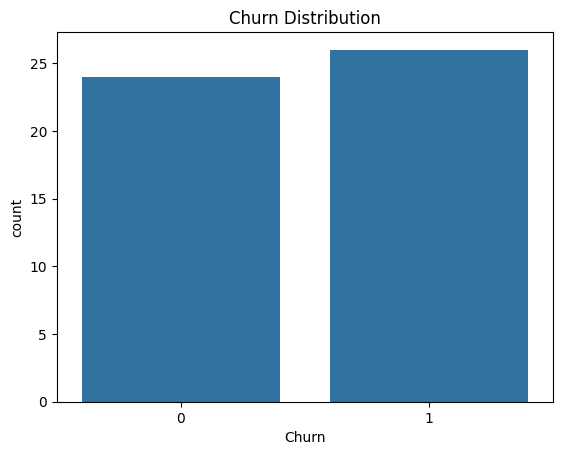

In [19]:

# Churn Distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()





       group  mean_retention
0    control        0.071429
1  treatment        0.166667


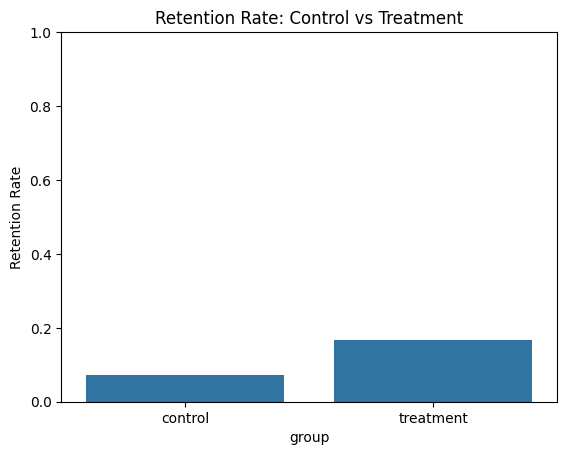

In [25]:
# --- Step 1: Calculate mean retention per group from actual A/B test data ---
retention_summary = high_risk.groupby('group', as_index=False)['retained'].mean()

# Optional: rename columns to avoid confusion
retention_summary.columns = ['group', 'mean_retention']

print(retention_summary)

# --- Step 2: Plot using seaborn ---
sns.barplot(x='group', y='mean_retention', data=retention_summary)
plt.title("Retention Rate: Control vs Treatment")
plt.ylabel("Retention Rate")
plt.ylim(0, 1)
plt.show()

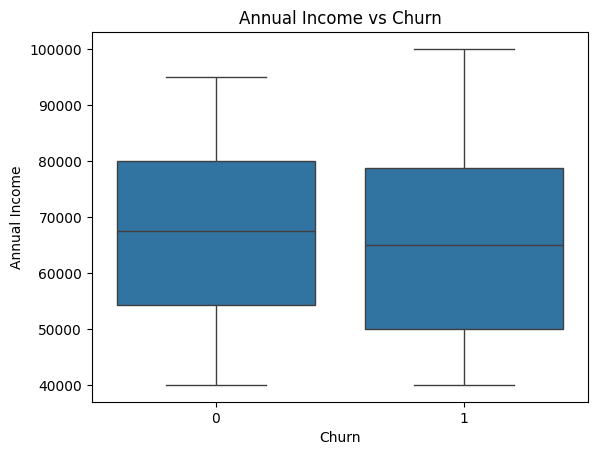

In [21]:
# Optional: Churn vs Annual Income
sns.boxplot(x='Churn', y='Annual Income', data=df)
plt.title("Annual Income vs Churn")
plt.show()

# ---------------------------
# 9️⃣ Insights & Recommendations
# ---------------------------

In [22]:

print("High-risk customers identified based on churn definition (>60 days since last purchase).")
print("Treatment group shows simulated retention improvement (20%).")
print("Recommendation: Implement targeted retention offers to reduce churn and increase revenue.")

High-risk customers identified based on churn definition (>60 days since last purchase).
Treatment group shows simulated retention improvement (20%).
Recommendation: Implement targeted retention offers to reduce churn and increase revenue.
